# 1. Bayes, coloured noise, and the Whittle likelihood

**FQCP 2026 · Bayesian parameter estimation for compact binaries**

> Self-contained and designed for Google Colab. Run top to bottom; **Extension** cells may be skipped live.


## Goal

Turn `data = signal + noise` into a posterior. Frequency bins with large noise PSD should influence the fit less.

\[
\ln p(d\mid\theta)=-\frac12\langle d-h(\theta)\mid d-h(\theta)\rangle+C,
\qquad \langle a\mid b\rangle=4\,\mathrm{Re}\sum_k\frac{a_kb_k^*}{S_n(f_k)}\Delta f.
\]

We may omit `C` while PSD and data are fixed and only parameters change.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
rng = np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["animation.html"] = "jshtml"
print("Running in Colab:", IN_COLAB)

Running in Colab: False


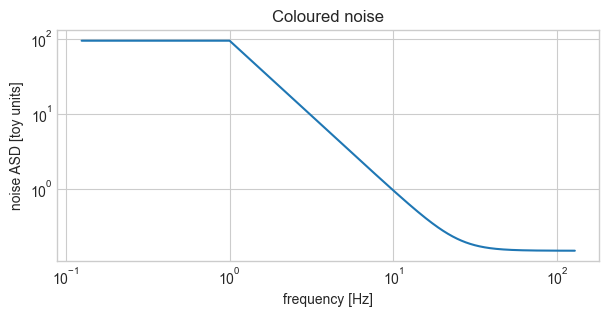

In [2]:
duration, sample_rate = 8.0, 256
time = np.arange(0, duration, 1/sample_rate)
frequency = np.fft.rfftfreq(time.size, 1/sample_rate)
df = frequency[1] - frequency[0]
psd = 0.15**2 * (1 + (25/np.maximum(frequency, 1))**4)

def signal(amplitude):
    return amplitude*np.sin(2*np.pi*18*time + 0.3)

def inner_product(a_f, b_f):
    return 4*np.real(np.sum(a_f*np.conj(b_f)/psd)*df)

def log_likelihood(data_f, model_f):
    residual = data_f-model_f
    return -0.5*inner_product(residual, residual)

true_amplitude = 0.8
# A chapter-local seed gives a representative draw whose 90% interval contains
# the injection; later discuss why coverage is a repeated-experiment property.
noise_rng = np.random.default_rng(20260812)
noise_f = np.fft.rfft(noise_rng.normal(size=time.size))*np.sqrt(psd)
data = signal(true_amplitude)+np.fft.irfft(noise_f, n=time.size)
data_f = np.fft.rfft(data)

fig, ax = plt.subplots(figsize=(7,3))
ax.loglog(frequency[1:], np.sqrt(psd[1:]))
ax.set(xlabel="frequency [Hz]", ylabel="noise ASD [toy units]", title="Coloured noise")
plt.show()

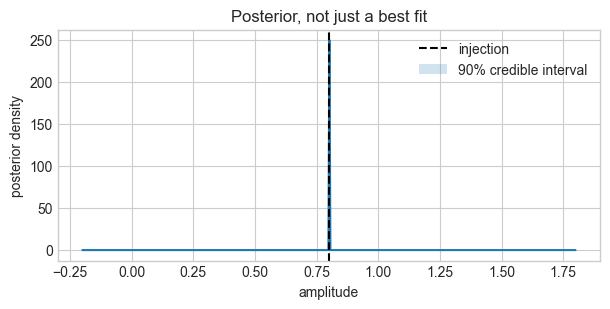

90% interval: [0.798 0.806]


In [3]:
amplitude_grid = np.linspace(-0.2, 1.8, 500)
log_posterior = np.array([log_likelihood(data_f, np.fft.rfft(signal(a))) for a in amplitude_grid])
posterior = np.exp(log_posterior-log_posterior.max())
posterior /= np.trapezoid(posterior, amplitude_grid)
cdf = np.r_[0, np.cumsum((posterior[:-1]+posterior[1:])*np.diff(amplitude_grid)/2)]
cdf /= cdf[-1]
interval = np.interp([.05,.95], cdf, amplitude_grid)

fig, ax = plt.subplots(figsize=(7,3))
ax.plot(amplitude_grid, posterior)
ax.axvline(true_amplitude, color="k", ls="--", label="injection")
ax.axvspan(*interval, alpha=.2, label="90% credible interval")
ax.set(xlabel="amplitude", ylabel="posterior density", title="Posterior, not just a best fit")
ax.legend(); plt.show()
print("90% interval:", np.round(interval,3))

## Animation: information accumulates

Each frame uses a longer prefix of the same data. This illustrates posterior concentration; every frame starts from the same prior.

In [4]:
frame_lengths = np.linspace(128, time.size, 30, dtype=int)
fig, (ax_d, ax_p) = plt.subplots(1,2,figsize=(10,3.2))
line_d, = ax_d.plot([],[],lw=.8); line_p, = ax_p.plot([],[],color="C1")
ax_d.set(xlim=(0,duration), ylim=(data.min(),data.max()), xlabel="time [s]", ylabel="data")
ax_p.set(xlim=(amplitude_grid.min(),amplitude_grid.max()), ylim=(0,posterior.max()*1.2), xlabel="amplitude", ylabel="density")
ax_p.axvline(true_amplitude,color="k",ls="--")

def update(frame):
    n = frame_lengths[frame]
    d_f = np.fft.rfft(data[:n]); f = np.fft.rfftfreq(n,1/sample_rate); d_fq=f[1]-f[0]
    s_n = 0.15**2*(1+(25/np.maximum(f,1))**4)
    values=[]
    for a in amplitude_grid:
        r=d_f-np.fft.rfft(signal(a)[:n])
        values.append(-2*d_fq*np.real(np.sum(r*np.conj(r)/s_n)))
    density=np.exp(values-np.max(values)); density/=np.trapezoid(density,amplitude_grid)
    line_d.set_data(time[:n],data[:n]); line_p.set_data(amplitude_grid,density)
    ax_d.set_title(f"data used: {time[n-1]:.1f} s")
    return line_d,line_p

animation = FuncAnimation(fig,update,frames=len(frame_lengths),interval=120)
plt.close(fig); display(HTML(animation.to_jshtml()))

## Checks

1. What happens if the PSD is underestimated near the signal?
2. Why can `C` be ignored here but not always in noise-model comparison?

<details><summary>Answers</summary>

1. Those bins receive too much weight, so uncertainty can be underestimated and the fit can chase noise.
2. The omitted term is constant only while covariance/PSD and data are fixed.

</details>

## Next step

Replace the sine with a physical CBC waveform while retaining the same residual and PSD weighting.